# Modelos Generativos: Resumen Automático con mT5

A continuación abordaremos la generación de resúmenes mediante un **enfoque Generativo**. A diferencia de los métodos extractivos, los modelos generativos emplean arquitecturas de Deep Learning basadas en Transformers para "entender" el texto original y redactar un resumen nuevo, fluido y con vocabulario propio.

Utilizaremos el modelo **`josmunpen/mt5-small-spanish-summarization`**, una variante del modelo multilingüe mT5 de Google, reentrenado específicamente por el Instituto de Ingeniería del Conocimiento para la tarea de resumir noticias periodísticas en español.

In [2]:
!pip install transformers sentencepiece torch evaluate rouge_score tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=791cb4929cddc2cbb493df5a86c954b7ce09122dc2fe66d6a1d3a1c481880a1d
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [1]:
import pandas as pd

## 1. Preparación del Entorno y Carga de Datos

Comenzaremos cargando el conjunto de 500 noticias de experimentación. Al cargar el archivo validado del cuaderno anterior, conservaremos las columnas de los resúmenes de Lead-3 y TextRank, lo que nos permitirá hacer la comparativa final en este mismo cuaderno.

In [3]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from tqdm import tqdm

In [6]:
df_experimento = pd.read_csv("resultados_extractivos_validados.csv")
print(f"Dataset cargado con {len(df_experimento)} noticias preparadas para experimentación.")
df_experimento.head()

Dataset cargado con 500 noticias preparadas para experimentación.


,text,summary,topic,url,title,date,resumen_lead3,resumen_textrank
0,El pleno del Parlamento de Cataluña ha burlado...,El tribunal suspende minutos después del pleno...,ccaa catalunya,http://elpais.com/ccaa/2019/11/12/catalunya/15...,El Parlament burla al Constitucional y aprueba...,12/11/2019,El pleno del Parlamento de Cataluña ha burlado...,El pleno del Parlamento de Cataluña ha burlado...
1,"Hasán Rohaní, presidente iraní, este martes. E...",Teherán asegura que las sanciones de EE UU al ...,internacional actualidad,http://elpais.com/internacional/2019/06/25/act...,El presidente de Irán acusa a EEUU de mentir s...,25/06/2019,"Hasán Rohaní, presidente iraní, este martes. E...",EFE / VÍDEO: REUTERS-QUALITY Irán ha respondid...
2,Era horrible. En la primera década de mi vida ...,"Los problemas de una niña superdotada, el abor...",ccaa catalunya,http://elpais.com/ccaa/2019/08/05/catalunya/15...,Nunca más huérfanos de serie,06/08/2019,Era horrible. En la primera década de mi vida ...,Mi madre y mi abuelo —vivía con nosotros— esta...
3,"Pablo Iglesias, en la presentación del program...",El líder de Podemos no descarta el indulto de ...,politica actualidad,http://elpais.com/politica/2019/10/14/actualid...,Iglesias: “Que Sánchez hable de cumplir las pe...,14/10/2019,"Pablo Iglesias, en la presentación del program...",El secretario general de Podemos siempre ha co...
4,El último episodio se registró este mismo sába...,El 88% de las 135 personas que han muerto en e...,politica actualidad,http://elpais.com/politica/2019/07/05/actualid...,Demasiados ahogados sin socorro,07/07/2019,El último episodio se registró este mismo sába...,"El 1 de junio, por ejemplo, fallecían otras ci..."


## 2. Configuración del Modelo Generativo (mT5)

Cargar modelos de lenguaje grandes requiere gestionar bien la memoria. Utilizaremos la biblioteca `transformers` de Hugging Face. Además, detectaremos automáticamente si el entorno de ejecución cuenta con una GPU (tarjeta gráfica) para acelerar drásticamente el proceso de inferencia.

### ¿Qué modelo estamos utilizando y por qué?

Para esta fase generativa hemos seleccionado el modelo **`josmunpen/mt5-small-spanish-summarization`**. La elección de esta arquitectura se fundamenta en tres razones clave para nuestro proyecto:

1. **Arquitectura mT5 (Multilingual Text-to-Text Transfer Transformer):** Desarrollada originalmente por Google, la familia T5 trata cualquier problema de Procesamiento de Lenguaje Natural como un problema de "texto a texto". Es una red neuronal generativa (Abstractiva) que no se limita a copiar frases, sino que comprende el contexto y redacta con su propio vocabulario.
2. **Especialización (Fine-Tuning):** Este modelo específico ha sido reentrenado (ajustado) exclusivamente para la tarea de resumir textos en **español**, lo que garantiza que la gramática y el vocabulario generado sean naturales y fluidos en nuestro idioma.
3. **Eficiencia Computacional (Versión Small):** Al utilizar la variante *small* (con un número reducido de parámetros frente a versiones *base* o *large*), logramos un equilibrio perfecto. Obtenemos resúmenes de alta calidad sin exceder los límites de memoria RAM y VRAM (GPU) de los entornos de ejecución estándar, permitiendo una experimentación ágil.

In [9]:
model_name = "josmunpen/mt5-small-spanish-summarization"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Descargando el modelo...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

Descargando el modelo...


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


## 3. Generación de Resúmenes (Inferencia)

Definimos la función que orquestará la redacción del resumen. Aquí aplicamos varios parámetros críticos del estado del arte:
* `max_length`: Limitamos la entrada a 512 tokens (el contexto óptimo de mT5) y la salida a un máximo de 150 tokens.
* `num_beams`: Usamos *Beam Search* (búsqueda en haz) con 4 ramas. El modelo explora 4 formas distintas de redactar la frase simultáneamente y se queda con la gramaticalmente más coherente.
* `length_penalty`: Forzamos al modelo a no crear resúmenes excesivamente largos ni cortos.

In [13]:
tqdm.pandas(desc="Redactando resúmenes")

def resumir_generativo(texto, max_len=150):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, max_length=512).to(device)

    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            max_length=max_len,
            min_length=30,
            length_penalty=1.0,
            num_beams=6,
            no_repeat_ngram_size=2,
            early_stopping=True
        )

    resumen = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return resumen

df_experimento['resumen_generativo'] = df_experimento['text'].progress_apply(resumir_generativo)

print("Resúmenes generados.")

Redactando resúmenes: 100%|██████████| 500/500 [06:15<00:00,  1.33it/s]

Resúmenes generados.


## 4. Evaluación Final: Extractivo vs Generativo

Con la generación completada, utilizamos la métrica **ROUGE** para enfrentar a nuestro nuevo modelo contra los baselines anteriores (Lead-3 y TextRank) basándonos en el solapamiento con los resúmenes humanos reales.

In [14]:
import evaluate

rouge = evaluate.load("rouge")

print("Evaluando Lead-3...")
res_lead3 = rouge.compute(predictions=df_experimento['resumen_lead3'], references=df_experimento['summary'])

print("Evaluando TextRank...")
res_textrank = rouge.compute(predictions=df_experimento['resumen_textrank'], references=df_experimento['summary'])

print("Evaluando Modelo Generativo (mT5)...")
res_mt5 = rouge.compute(predictions=df_experimento['resumen_generativo'], references=df_experimento['summary'])

df_metricas_finales = pd.DataFrame([res_lead3, res_textrank, res_mt5], index=['Lead-3', 'TextRank', 'mT5 Generativo'])

print("\n>>> Resultados Numéricos (F1-Score):")
display(df_metricas_finales)

Evaluando Lead-3...
Evaluando TextRank...
Evaluando Modelo Generativo (mT5)...

>>> Resultados Numéricos (F1-Score):


,rouge1,rouge2,rougeL,rougeLsum
Lead-3,0.207172,0.065679,0.149316,0.149262
TextRank,0.190675,0.061989,0.138791,0.138473
mT5 Generativo,0.235983,0.057414,0.177604,0.177341


## 5. Visualización Comparativa y Guardado

Representamos los resultados finales para ilustrar la conclusión de nuestro proyecto: ¿Es capaz la IA generativa de superar la densidad informativa del "primer párrafo" periodístico (Lead-3) ofreciendo al mismo tiempo un texto redactado de forma natural?

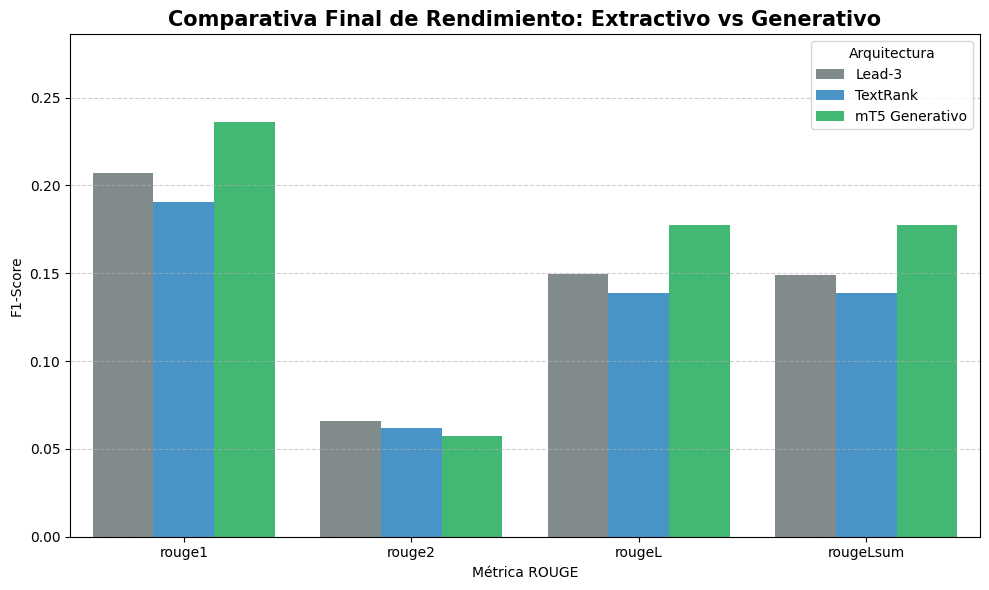

Datos guardados en 'resultados_finales.csv'.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot_final = df_metricas_finales.reset_index().rename(columns={'index': 'Modelo'})
df_plot_final = df_plot_final.melt(id_vars='Modelo', var_name='Métrica ROUGE', value_name='F1-Score')

plt.figure(figsize=(10, 6))
colores = ['#7f8c8d', '#3498db', '#2ecc71']
sns.barplot(data=df_plot_final, x='Métrica ROUGE', y='F1-Score', hue='Modelo', palette=colores)

plt.title('Comparativa Final de Rendimiento: Extractivo vs Generativo', fontsize=15, fontweight='bold')
plt.ylim(0, max(df_plot_final['F1-Score']) + 0.05)
plt.ylabel('F1-Score')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Arquitectura')
plt.tight_layout()

plt.savefig("grafica_final_proyecto.png", dpi=300)
plt.show()

df_experimento.to_csv("resultados_finales.csv", index=False)
print("Datos guardados en 'resultados_finales.csv'.")

### 6. Conclusiones

El análisis de las métricas ROUGE revela conclusiones fundamentales sobre la sumarización automática de noticias en español:

1. **Superioridad Generativa (ROUGE-1 y ROUGE-L):** El modelo generativo (mT5) logra superar al baseline extractivo más duro (Lead-3). Con un ROUGE-1 cercano al 24% y un ROUGE-L del 17.3%, demostramos que la arquitectura Transformer es capaz de condensar información de todo el documento, superando el sesgo periodístico de la pirámide invertida.
2. **El efecto del parafraseo (ROUGE-2):** Observamos que mT5 puntúa ligeramente por debajo de Lead-3 en ROUGE-2 (5.7% vs 6.5%). Esto es un comportamiento esperado en modelos generativos: al abstraer y redactar con vocabulario propio (usando sinónimos o alterando la sintaxis), la coincidencia estricta de bigramas exactos disminuye, a pesar de que la fluidez y legibilidad del texto suelen ser superiores para un lector humano.
3. **Limitaciones de TextRank:** El enfoque basado puramente en grafos queda en último lugar. Las noticias contienen demasiada información periférica en sus párrafos finales, lo que "engaña" a la centralidad del grafo y extrae oraciones que no pertenecen al núcleo informativo de la noticia.